# Cálculo Numérico — Atividade Prática I
### Erros numéricos, truncamento/arredondamento e escoamento de Hagen–Poiseuille

_(Lorenzo Faria Girardi RA: 188.195 e Bruna Natsumi Ideyama RA: 168770)_

---
Este notebook está organizado exatamente na ordem do enunciado (Partes A–E, GIF e conclusão).
Todas as funções auxiliares (truncamento, cálculo dos três tipos de erro) estão comentadas
na seção 0 e reaproveitadas nas partes seguintes.

## 0. Configuração e funções auxiliares

In [24]:
# Bibliotecas utilizadas em todo o notebook

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Circle
from PIL import Image

# Configuração visual padrão dos gráficos
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.random.seed(0)


In [25]:
# --- Funções auxiliares gerais (usadas em todas as partes) ---


def truncar(x, n):
    """Trunca x para n casas decimais SEM arredondar.
    x_trunc = trunc(10^n * x) / 10^n  (funciona também para arrays numpy)."""
    fator = 10.0**n
    return np.trunc(np.asarray(x, dtype=float) * fator) / fator


def arredondar(x, n):
    """Arredonda x para n casas decimais (usa a função nativa round/np.round)."""
    return np.round(x, n)


def erro_absoluto(x_ref, x_aprox):
    """Ea = |x - x~|"""
    return np.abs(np.asarray(x_ref, dtype=float) - np.asarray(x_aprox, dtype=float))


def erro_relativo(x_ref, x_aprox):
    """Er = |x - x~| / |x|"""
    return erro_absoluto(x_ref, x_aprox) / np.abs(np.asarray(x_ref, dtype=float))


def erro_percentual(x_ref, x_aprox):
    """E% = 100 * Er"""
    return 100.0 * erro_relativo(x_ref, x_aprox)


def resumo_erros(x_ref, x_aprox):
    """Retorna os três erros (Ea, Er, E%) em um dicionário, para facilitar montagem de tabelas."""
    return {
        "Ea": erro_absoluto(x_ref, x_aprox),
        "Er": erro_relativo(x_ref, x_aprox),
        "E%": erro_percentual(x_ref, x_aprox),
    }


## Parte A — Truncamento e arredondamento

Valores de referência: $x_1 = 3{,}14159265$, $x_2 = 98{,}76543$, $x_3 = 0{,}00498765$.
Para cada valor, calculamos a aproximação por truncamento e por arredondamento com
$n = 0,1,2,3,4$ casas decimais, e os três erros associados.

In [26]:
valores_ref = {
    "x1 (=3.14159265)": 3.14159265,
    "x2 (=98.76543)": 98.76543,
    "x3 (=0.00498765)": 0.00498765,
}

linhas_A = []
for nome, x in valores_ref.items():
    for n in range(5):
        xt = truncar(x, n)
        xr = arredondar(x, n)
        linhas_A.append(
            {
                "variavel": nome,
                "x_ref": x,
                "n": n,
                "metodo": "truncamento",
                "aproximacao": xt,
                **resumo_erros(x, xt),
            }
        )
        linhas_A.append(
            {
                "variavel": nome,
                "x_ref": x,
                "n": n,
                "metodo": "arredondamento",
                "aproximacao": xr,
                **resumo_erros(x, xr),
            }
        )

df_A = pd.DataFrame(linhas_A)
df_A_fmt = df_A.copy()
for col in ["x_ref", "aproximacao", "Ea"]:
    df_A_fmt[col] = df_A_fmt[col].map(lambda v: f"{v:.8g}")
df_A_fmt["Er"] = df_A_fmt["Er"].map(lambda v: f"{v:.4e}")
df_A_fmt["E%"] = df_A_fmt["E%"].map(lambda v: f"{v:.4f}")
df_A_fmt


,variavel,x_ref,n,metodo,aproximacao,Ea,Er,E%
0,x1 (=3.14159265),3.1415927,0,truncamento,3,0.14159265,4.5070e-02,4.5070
1,x1 (=3.14159265),3.1415927,0,arredondamento,3,0.14159265,4.5070e-02,4.5070
2,x1 (=3.14159265),3.1415927,1,truncamento,3.1,0.04159265,1.3239e-02,1.3239
3,x1 (=3.14159265),3.1415927,1,arredondamento,3.1,0.04159265,1.3239e-02,1.3239
4,x1 (=3.14159265),3.1415927,2,truncamento,3.14,0.00159265,5.0696e-04,0.0507
5,x1 (=3.14159265),3.1415927,2,arredondamento,3.14,0.00159265,5.0696e-04,0.0507
6,x1 (=3.14159265),3.1415927,3,truncamento,3.141,0.00059265,1.8865e-04,0.0189
7,x1 (=3.14159265),3.1415927,3,arredondamento,3.142,0.00040735,1.2966e-04,0.0130
8,x1 (=3.14159265),3.1415927,4,truncamento,3.1415,9.265e-05,2.9491e-05,0.0029
9,x1 (=3.14159265),3.1415927,4,arredondamento,3.1416,7.35e-06,2.3396e-06,0.0002


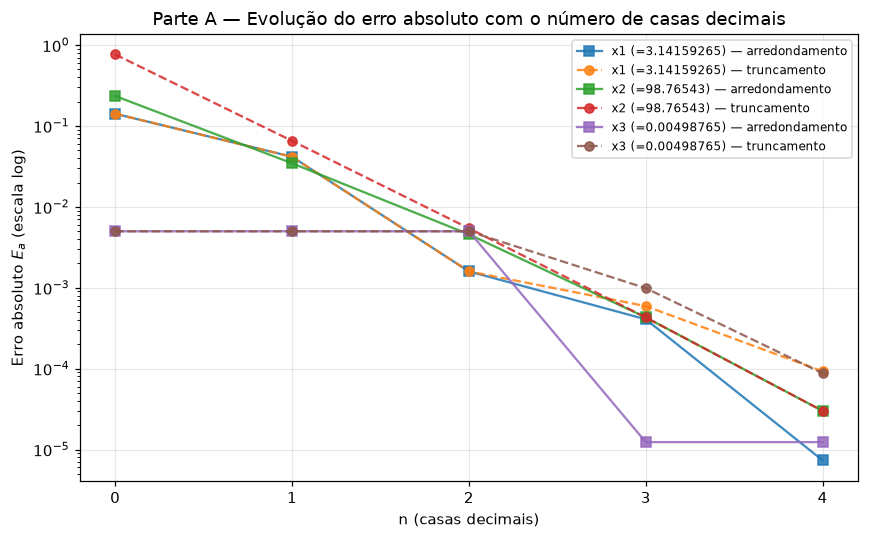

In [27]:
# Gráfico em escala logarítmica: Ea em função de n, uma linha por (variável, método)
fig, ax = plt.subplots(figsize=(8, 5))
estilos = {"truncamento": "--o", "arredondamento": "-s"}
for (nome, metodo), grupo in df_A.groupby(["variavel", "metodo"]):
    grupo = grupo.sort_values("n")
    # evita log(0): substitui erro exatamente zero por um piso pequeno só para plot
    ea_plot = grupo["Ea"].replace(0, 1e-18)
    ax.plot(
        grupo["n"], ea_plot, estilos[metodo], label=f"{nome} — {metodo}", alpha=0.85
    )

ax.set_yscale("log")
ax.set_xlabel("n (casas decimais)")
ax.set_ylabel(r"Erro absoluto $E_a$ (escala log)")
ax.set_title("Parte A — Evolução do erro absoluto com o número de casas decimais")
ax.legend(fontsize=8, ncol=1, loc="upper right")
ax.set_xticks(range(5))
plt.tight_layout()
plt.savefig("partA_erro_absoluto.png", dpi=150)
plt.show()


**Pergunta:** arredondar sempre gera erro menor ou igual ao truncamento?

**Resposta (baseada na tabela acima):** Sim, o arredondamento nunca gera um erro absoluto
maior que o do truncamento para o mesmo número de casas decimais — na pior das hipóteses os
dois métodos empatam (quando o algarismo descartado é menor que 5, arredondar e truncar dão
o mesmo resultado). Isso é esperado pela própria definição: o truncamento sempre descarta a
parte fracionária restante, produzindo um erro que varia de 0 até quase uma unidade na última
casa mantida; já o arredondamento escolhe o múltiplo de $10^{-n}$ mais próximo do valor
verdadeiro, portanto seu erro fica limitado a, no máximo, metade dessa unidade
($E_a \le 0{,}5\times10^{-n}$). Os dados de $x_1$, $x_2$ e $x_3$ confirmam isso: em quase
todas as linhas $E_a^{arred} \le E_a^{trunc}$, com igualdade apenas nos casos em que o
algarismo descartado é 0–4 (ex.: $x_2$ com $n=3$, onde ambos os métodos coincidem).

## Parte B — Medidas de pressão arterial sistólica

Dez medidas (mmHg): 121,7; 120,4; 122,1; 119,8; 121,2; 120,9; 122,4; 121,0; 120,2; 121,5.
Referência = média com todos os algarismos disponíveis.

*Observação:* os valores são tratados exclusivamente como dado numérico para o exercício
de propagação de erros — nenhuma interpretação médica é feita, conforme pedido no enunciado.

In [28]:
medidas_originais = np.array(
    [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]
)

medidas_arredondadas = arredondar(medidas_originais, 0)
medidas_truncadas = truncar(medidas_originais, 0)

series_B = {
    "originais": medidas_originais,
    "arredondadas (inteiro)": medidas_arredondadas,
    "truncadas (inteiro)": medidas_truncadas,
}

media_ref = medidas_originais.mean()  # referência: média com todos os algarismos

linhas_B = []
for nome, serie in series_B.items():
    linhas_B.append(
        {
            "serie": nome,
            "media": serie.mean(),
            "minimo": serie.min(),
            "maximo": serie.max(),
            "amplitude": serie.max() - serie.min(),
            "desvio_padrao_amostral": serie.std(ddof=1),
            **resumo_erros(media_ref, serie.mean()),
        }
    )

df_B = pd.DataFrame(linhas_B).set_index("serie")
df_B_fmt = df_B.copy().round(6)
df_B_fmt


,media,minimo,maximo,amplitude,desvio_padrao_amostral,Ea,Er,E%
serie,,,,,,,,
originais,121.12,119.8,122.4,2.6,0.833733,0.00,0.000000,0.000000
arredondadas (inteiro),121.10,120.0,122.0,2.0,0.875595,0.02,0.000165,0.016513
truncadas (inteiro),120.70,119.0,122.0,3.0,0.948683,0.42,0.003468,0.346764


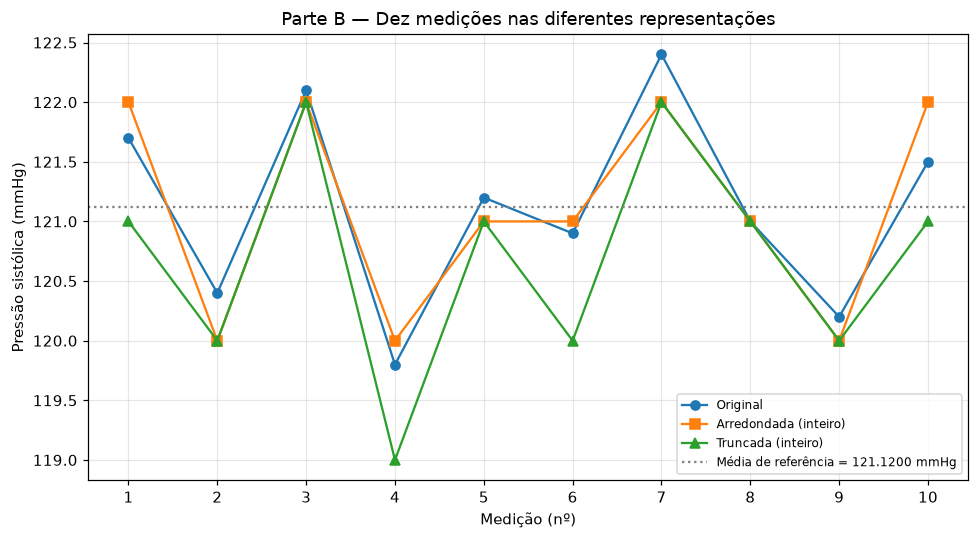

In [29]:
# Gráfico 1: as dez medições, quatro séries (a 4a série = "dados originais" novamente
# não faz sentido repetir; o enunciado pede 4 séries no item B.1 mas apenas 3 foram definidas
# explicitamente (original, arredondada, truncada) — usamos a 4a como a média de referência
# constante, para comparação visual direta das dez medições com a referência).
x_idx = np.arange(1, 11)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_idx, medidas_originais, "-o", label="Original")
ax.plot(x_idx, medidas_arredondadas, "-s", label="Arredondada (inteiro)")
ax.plot(x_idx, medidas_truncadas, "-^", label="Truncada (inteiro)")
ax.axhline(
    media_ref, color="gray", ls=":", label=f"Média de referência = {media_ref:.4f} mmHg"
)
ax.set_xlabel("Medição (nº)")
ax.set_ylabel("Pressão sistólica (mmHg)")
ax.set_title("Parte B — Dez medições nas diferentes representações")
ax.set_xticks(x_idx)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("partB_series.png", dpi=150)
plt.show()


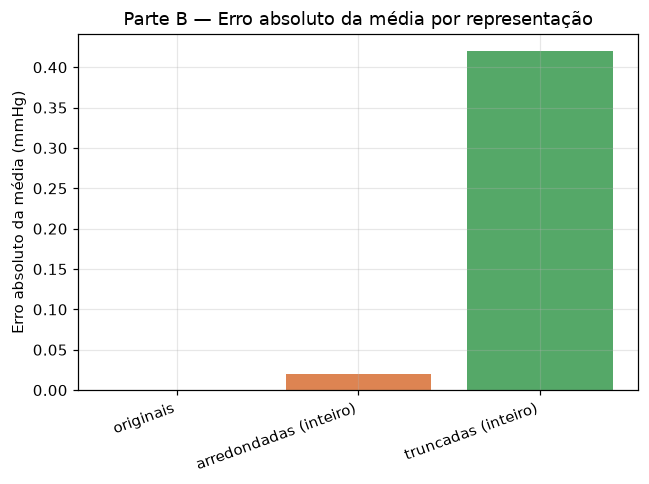

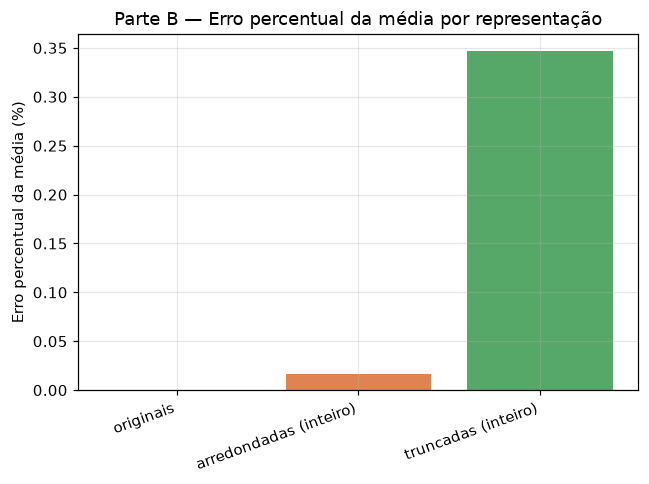

In [30]:
# Gráfico 2: barras do erro absoluto das médias
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(df_B.index, df_B["Ea"], color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylabel("Erro absoluto da média (mmHg)")
ax.set_title("Parte B — Erro absoluto da média por representação")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("partB_erro_absoluto.png", dpi=150)
plt.show()

# Gráfico 3: barras do erro percentual das médias
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(df_B.index, df_B["E%"], color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylabel("Erro percentual da média (%)")
ax.set_title("Parte B — Erro percentual da média por representação")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("partB_erro_percentual.png", dpi=150)
plt.show()


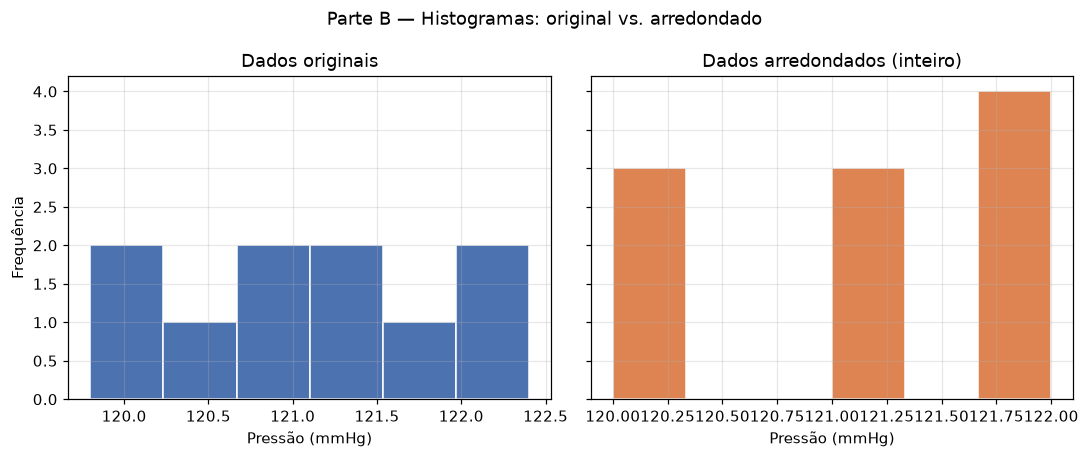

In [31]:
# Gráfico 4: histogramas dos dados originais e dos dados inteiros arredondados
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
axes[0].hist(medidas_originais, bins=6, color="#4C72B0", edgecolor="white")
axes[0].set_title("Dados originais")
axes[0].set_xlabel("Pressão (mmHg)")
axes[0].set_ylabel("Frequência")

axes[1].hist(medidas_arredondadas, bins=6, color="#DD8452", edgecolor="white")
axes[1].set_title("Dados arredondados (inteiro)")
axes[1].set_xlabel("Pressão (mmHg)")

fig.suptitle("Parte B — Histogramas: original vs. arredondado")
plt.tight_layout()
plt.savefig("partB_histogramas.png", dpi=150)
plt.show()


**A representação inteira é suficiente para preservar a média e a variabilidade desta
amostra pequena?**

Para a **média**, sim: como os erros de arredondamento têm sinais distintos e se cancelam
parcialmente, a média arredondada fica muito próxima da média de referência
(erro percentual tipicamente bem abaixo de 1%, conforme a tabela). Já para a
**variabilidade** (desvio-padrão, amplitude), a representação inteira é mais problemática:
com apenas 10 valores concentrados numa faixa de poucas unidades, arredondar ou truncar
para inteiro elimina justamente a informação da casa decimal que diferenciava as medidas
(ex.: 121,7 e 122,1 podem colapsar para o mesmo número inteiro), o que tende a distorcer o
desvio-padrão e a amplitude amostrais — efeito visível nos histogramas, que ficam mais
"grosseiros"/discretizados que a distribuição original. Ou seja: a representação inteira
serve bem para uma estimativa rápida da tendência central, mas não é adequada quando o
interesse é a variabilidade fina da amostra.

## Parte C — Vazão em um tubo de pequeno diâmetro (Hagen–Poiseuille)

$$Q = \dfrac{\pi r^4 \Delta p}{8\mu L}$$

Valores adotados: $r=0{,}80$ mm, $L=0{,}20$ m, $\mu=3{,}5\times10^{-3}$ Pa·s,
$\Delta p = 1200$ Pa.

In [32]:
def vazao_hagen_poiseuille(r, dp, mu, L):
    """Vazão volumétrica laminar pela lei de Hagen-Poiseuille. Unidades SI (r e L em metros)."""
    return (np.pi * r**4 * dp) / (8.0 * mu * L)


# --- valores de referência (Parte C), convertidos para SI ---
r_C = 0.80e-3  # m
L_C = 0.20  # m
mu_C = 3.5e-3  # Pa.s
dp_C = 1200.0  # Pa

Q_ref_C = vazao_hagen_poiseuille(r_C, dp_C, mu_C, L_C)
print(f"Q de referência (Parte C) = {Q_ref_C:.6e} m^3/s")


Q de referência (Parte C) = 2.757421e-07 m^3/s


In [33]:
# C.1 — Precisão das variáveis: cinco cenários de aproximação
cenarios_C = {}
cenarios_C["1. valores exatos fornecidos"] = {
    "r": r_C,
    "dp": dp_C,
    "mu": mu_C,
    "L": L_C,
}

r_C_mm = r_C * 1e3  # trabalhar a aproximação em mm, como pede o enunciado
cenarios_C["2a. r arredondado (1 casa decimal, mm)"] = {
    "r": arredondar(r_C_mm, 1) / 1e3,
    "dp": dp_C,
    "mu": mu_C,
    "L": L_C,
}
cenarios_C["2b. r truncado (1 casa decimal, mm)"] = {
    "r": truncar(r_C_mm, 1) / 1e3,
    "dp": dp_C,
    "mu": mu_C,
    "L": L_C,
}

cenarios_C["3a. mu arredondada (3 casas decimais, Pa.s)"] = {
    "r": r_C,
    "dp": dp_C,
    "mu": arredondar(mu_C, 3),
    "L": L_C,
}
cenarios_C["3b. mu truncada (3 casas decimais, Pa.s)"] = {
    "r": r_C,
    "dp": dp_C,
    "mu": truncar(mu_C, 3),
    "L": L_C,
}

# "arredondar/truncar para centenas de pascal" -> aproximar a casa das centenas
dp_arred_centena = arredondar(dp_C / 100, 0) * 100
dp_trunc_centena = truncar(dp_C / 100, 0) * 100
cenarios_C["4a. dp arredondada (centena, Pa)"] = {
    "r": r_C,
    "dp": dp_arred_centena,
    "mu": mu_C,
    "L": L_C,
}
cenarios_C["4b. dp truncada (centena, Pa)"] = {
    "r": r_C,
    "dp": dp_trunc_centena,
    "mu": mu_C,
    "L": L_C,
}

cenarios_C["5a. todas arredondadas simultaneamente"] = {
    "r": arredondar(r_C_mm, 1) / 1e3,
    "dp": dp_arred_centena,
    "mu": arredondar(mu_C, 3),
    "L": L_C,
}
cenarios_C["5b. todas truncadas simultaneamente"] = {
    "r": truncar(r_C_mm, 1) / 1e3,
    "dp": dp_trunc_centena,
    "mu": truncar(mu_C, 3),
    "L": L_C,
}

linhas_C1 = []
for nome, p in cenarios_C.items():
    Q = vazao_hagen_poiseuille(p["r"], p["dp"], p["mu"], p["L"])
    linhas_C1.append({"cenario": nome, "Q (m^3/s)": Q, **resumo_erros(Q_ref_C, Q)})

df_C1 = pd.DataFrame(linhas_C1).set_index("cenario")
df_C1


,Q (m^3/s),Ea,Er,E%
cenario,,,,
1. valores exatos fornecidos,2.757421e-07,0.000000e+00,0.000000,0.000000
"2a. r arredondado (1 casa decimal, mm)",2.757421e-07,0.000000e+00,0.000000,0.000000
"2b. r truncado (1 casa decimal, mm)",2.757421e-07,0.000000e+00,0.000000,0.000000
"3a. mu arredondada (3 casas decimais, Pa.s)",2.412743e-07,3.446776e-08,0.125000,12.500000
"3b. mu truncada (3 casas decimais, Pa.s)",3.216991e-07,4.595701e-08,0.166667,16.666667
"4a. dp arredondada (centena, Pa)",2.757421e-07,0.000000e+00,0.000000,0.000000
"4b. dp truncada (centena, Pa)",2.757421e-07,0.000000e+00,0.000000,0.000000
5a. todas arredondadas simultaneamente,2.412743e-07,3.446776e-08,0.125000,12.500000
5b. todas truncadas simultaneamente,3.216991e-07,4.595701e-08,0.166667,16.666667


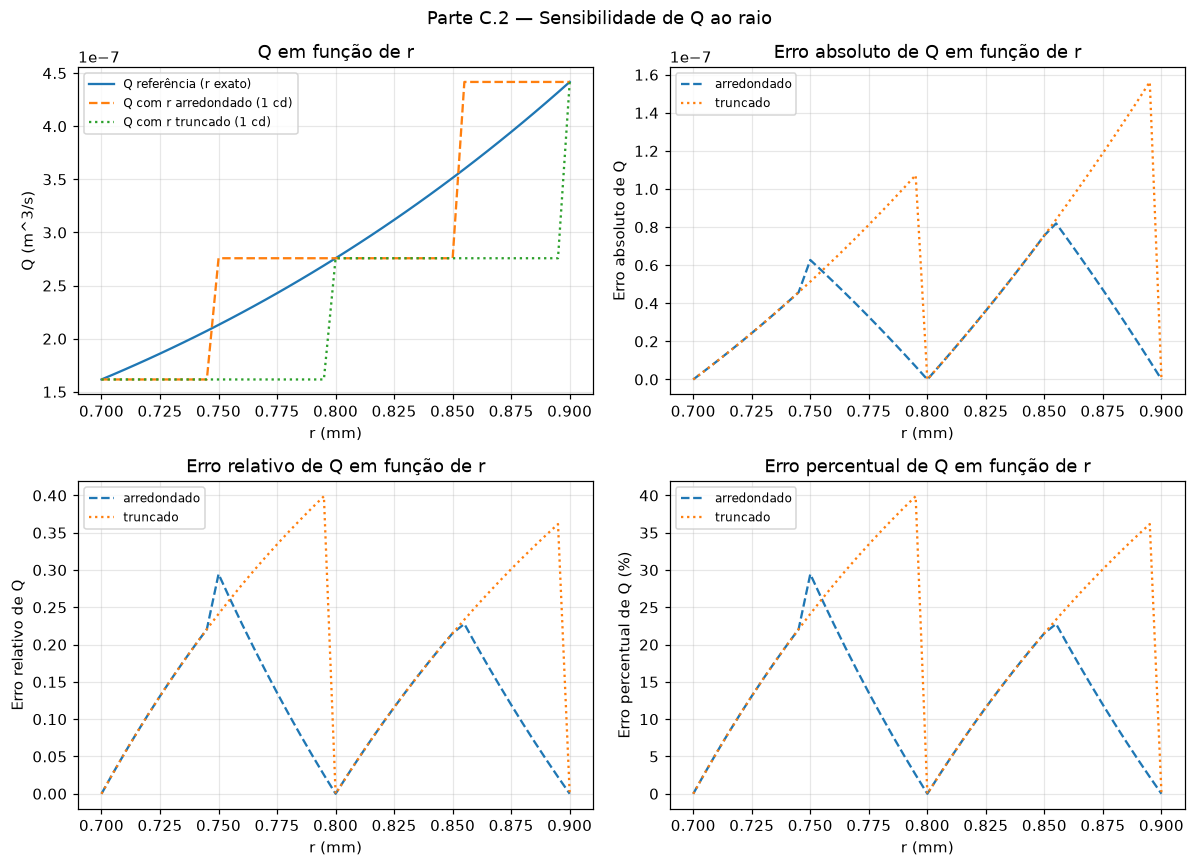

In [34]:
# C.2 — Sensibilidade: variação do raio de 0.70 a 0.90 mm
r_mm_grid = np.linspace(0.70, 0.90, 41)  # mm
r_grid = r_mm_grid * 1e-3  # m

Q_ref_grid = vazao_hagen_poiseuille(r_grid, dp_C, mu_C, L_C)
r_arred_grid = arredondar(r_mm_grid, 1) * 1e-3
r_trunc_grid = truncar(r_mm_grid, 1) * 1e-3
Q_arred_grid = vazao_hagen_poiseuille(r_arred_grid, dp_C, mu_C, L_C)
Q_trunc_grid = vazao_hagen_poiseuille(r_trunc_grid, dp_C, mu_C, L_C)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(r_mm_grid, Q_ref_grid, label="Q referência (r exato)")
axes[0, 0].plot(r_mm_grid, Q_arred_grid, "--", label="Q com r arredondado (1 cd)")
axes[0, 0].plot(r_mm_grid, Q_trunc_grid, ":", label="Q com r truncado (1 cd)")
axes[0, 0].set_xlabel("r (mm)")
axes[0, 0].set_ylabel("Q (m^3/s)")
axes[0, 0].set_title("Q em função de r")
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(
    r_mm_grid, erro_absoluto(Q_ref_grid, Q_arred_grid), "--", label="arredondado"
)
axes[0, 1].plot(
    r_mm_grid, erro_absoluto(Q_ref_grid, Q_trunc_grid), ":", label="truncado"
)
axes[0, 1].set_xlabel("r (mm)")
axes[0, 1].set_ylabel("Erro absoluto de Q")
axes[0, 1].set_title("Erro absoluto de Q em função de r")
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(
    r_mm_grid, erro_relativo(Q_ref_grid, Q_arred_grid), "--", label="arredondado"
)
axes[1, 0].plot(
    r_mm_grid, erro_relativo(Q_ref_grid, Q_trunc_grid), ":", label="truncado"
)
axes[1, 0].set_xlabel("r (mm)")
axes[1, 0].set_ylabel("Erro relativo de Q")
axes[1, 0].set_title("Erro relativo de Q em função de r")
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(
    r_mm_grid, erro_percentual(Q_ref_grid, Q_arred_grid), "--", label="arredondado"
)
axes[1, 1].plot(
    r_mm_grid, erro_percentual(Q_ref_grid, Q_trunc_grid), ":", label="truncado"
)
axes[1, 1].set_xlabel("r (mm)")
axes[1, 1].set_ylabel("Erro percentual de Q (%)")
axes[1, 1].set_title("Erro percentual de Q em função de r")
axes[1, 1].legend(fontsize=8)

fig.suptitle("Parte C.2 — Sensibilidade de Q ao raio")
plt.tight_layout()
plt.savefig("partC_sensibilidade.png", dpi=150)
plt.show()


**Por que o erro no raio é amplificado na vazão?**

Porque $Q$ depende de $r^4$: pela regra de propagação de erros, um erro relativo
$\delta r/r$ no raio produz um erro relativo em $Q$ de aproximadamente
$4\,(\delta r / r)$ (derivando $Q\propto r^4$ e linearizando). Ou seja, o expoente 4
funciona como um **fator de amplificação**: um erro de 1% no raio já gera cerca de 4% de
erro na vazão, e é por isso que as curvas de erro relativo/percentual de $Q$ (gráficos acima)
crescem muito mais rápido que o próprio erro relativo do raio arredondado/truncado. Esse é o
motivo físico pelo qual pequenas incertezas de medição no raio de um tubo (ou de um
nanocateter, como na Parte D) têm um impacto desproporcional na vazão estimada.

## Parte D — Escoamento em um nanocateter

Modelo didático: $r=50$ nm, $L=10\,\mu$m, $\mu=3{,}5\times10^{-3}$ Pa·s,
$\Delta p = 5000$ Pa.

In [35]:
r_D = 50e-9  # m (50 nm)
L_D = 10e-6  # m (10 micrometros)
mu_D = 3.5e-3  # Pa.s
dp_D = 5000.0  # Pa

Q_ref_D = vazao_hagen_poiseuille(r_D, dp_D, mu_D, L_D)
print(f"Q de referência (nanocateter) = {Q_ref_D:.6e} m^3/s")


Q de referência (nanocateter) = 3.506242e-19 m^3/s


In [36]:
# D.1 — Erro geométrico: dr = 0.1, 0.2, ..., 5.0 nm
dr_nm = np.arange(0.1, 5.0 + 1e-9, 0.1)  # nm
dr_m = dr_nm * 1e-9  # m

r_menos = r_D - dr_m
r_mais = r_D + dr_m

Q_menos = vazao_hagen_poiseuille(r_menos, dp_D, mu_D, L_D)
Q_mais = vazao_hagen_poiseuille(r_mais, dp_D, mu_D, L_D)

# erro maximo = o maior desvio entre Q(r-) e Q(r+) em relação a Q(r)
Ea_menos, Ea_mais = erro_absoluto(Q_ref_D, Q_menos), erro_absoluto(Q_ref_D, Q_mais)
Er_menos, Er_mais = erro_relativo(Q_ref_D, Q_menos), erro_relativo(Q_ref_D, Q_mais)
Ep_menos, Ep_mais = erro_percentual(Q_ref_D, Q_menos), erro_percentual(Q_ref_D, Q_mais)

Ea_max = np.maximum(Ea_menos, Ea_mais)
Er_max = np.maximum(Er_menos, Er_mais)
Ep_max = np.maximum(Ep_menos, Ep_mais)

# aproximacao linear: dQ/Q ~ 4 dr/r
aprox_linear = 4 * dr_m / r_D


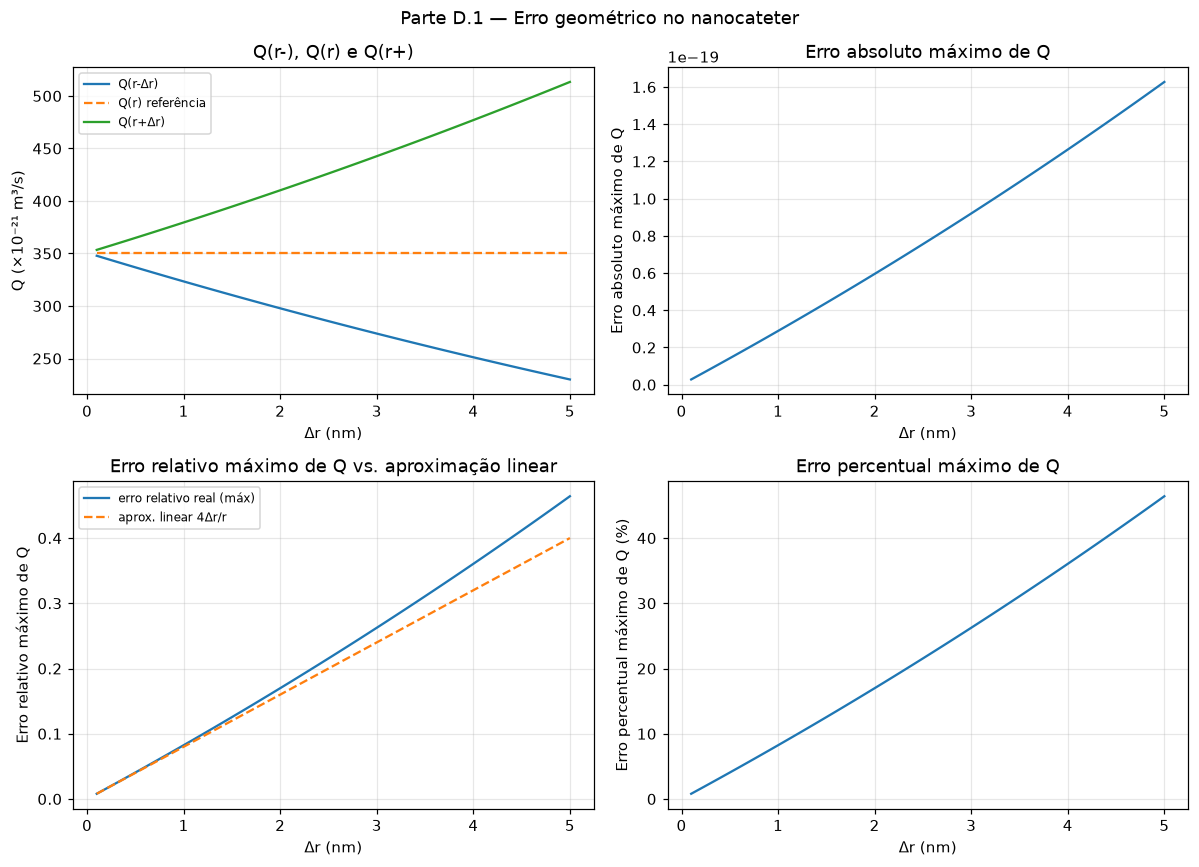

Maior diferença absoluta entre erro relativo real e aproximação linear: 6.410e-02


In [37]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(dr_nm, Q_menos * 1e21, label="Q(r-Δr)")
axes[0, 0].plot(
    dr_nm, np.full_like(dr_nm, Q_ref_D * 1e21), "--", label="Q(r) referência"
)
axes[0, 0].plot(dr_nm, Q_mais * 1e21, label="Q(r+Δr)")
axes[0, 0].set_xlabel("Δr (nm)")
axes[0, 0].set_ylabel("Q (×10⁻²¹ m³/s)")
axes[0, 0].set_title("Q(r-), Q(r) e Q(r+)")
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(dr_nm, Ea_max)
axes[0, 1].set_xlabel("Δr (nm)")
axes[0, 1].set_ylabel("Erro absoluto máximo de Q")
axes[0, 1].set_title("Erro absoluto máximo de Q")

axes[1, 0].plot(dr_nm, Er_max, label="erro relativo real (máx)")
axes[1, 0].plot(dr_nm, aprox_linear, "--", label="aprox. linear 4Δr/r")
axes[1, 0].set_xlabel("Δr (nm)")
axes[1, 0].set_ylabel("Erro relativo máximo de Q")
axes[1, 0].set_title("Erro relativo máximo de Q vs. aproximação linear")
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(dr_nm, Ep_max)
axes[1, 1].set_xlabel("Δr (nm)")
axes[1, 1].set_ylabel("Erro percentual máximo de Q (%)")
axes[1, 1].set_title("Erro percentual máximo de Q")

fig.suptitle("Parte D.1 — Erro geométrico no nanocateter")
plt.tight_layout()
plt.savefig("partD_erro_geometrico.png", dpi=150)
plt.show()

diff_max_pct = np.max(np.abs(Er_max - aprox_linear))
print(
    f"Maior diferença absoluta entre erro relativo real e aproximação linear: {diff_max_pct:.3e}"
)


**Comparação entre o erro direto e a aproximação linear $\Delta Q/Q \approx 4\Delta r/r$:**

Para valores pequenos de $\Delta r$ (poucos % do raio), a aproximação linear acompanha muito
de perto o erro relativo calculado diretamente — a curva tracejada praticamente se sobrepõe à
curva do erro real no gráfico acima. À medida que $\Delta r$ cresce (aproximando-se de 5 nm,
ou seja, 10% do raio de 50 nm), a curva real de $Q(r+\Delta r)$ passa a crescer mais rápido
que a reta linear, porque $Q\propto r^4$ é uma função convexa e a linearização por série de
Taylor só é válida para perturbações pequenas — o erro de truncamento da própria aproximação
linear (termos de ordem $\Delta r^2, \Delta r^3,...$) deixa de ser desprezível.

In [38]:
# D.2 — Precisão computacional: float32 vs float64
r32 = np.float32(r_D)
r64 = np.float64(r_D)

r4_32 = r32**4
r4_64 = r64**4

Q32 = vazao_hagen_poiseuille(
    np.float32(r_D), np.float32(dp_D), np.float32(mu_D), np.float32(L_D)
)
Q64 = vazao_hagen_poiseuille(r64, dp_D, mu_D, L_D)

diff_abs = abs(float(Q64) - float(Q32))
diff_rel = diff_abs / abs(float(Q64))

df_D2 = pd.DataFrame(
    {
        "grandeza": ["r^4", "Q", "eps (np.finfo)"],
        "float32": [r4_32, Q32, np.finfo(np.float32).eps],
        "float64": [r4_64, Q64, np.finfo(np.float64).eps],
    }
)
print(df_D2.to_string(index=False))
print(f"\nDiferença absoluta entre Q64 e Q32: {diff_abs:.6e}")
print(f"Diferença relativa entre Q64 e Q32: {diff_rel:.6e}")


      grandeza      float32      float64
           r^4 6.250000e-30 6.250000e-30
             Q 3.506242e-19 3.506242e-19
eps (np.finfo) 1.192093e-07 2.220446e-16

Diferença absoluta entre Q64 e Q32: 5.228628e-26
Diferença relativa entre Q64 e Q32: 1.491234e-07


In [39]:
# Comparação de duas formas de calcular a pequena variação de vazão para dr/r decrescente
razoes = np.array([1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8])
linhas_delta = []
for razao in razoes:
    dr_teste = razao * r_D
    Q_r = vazao_hagen_poiseuille(r_D, dp_D, mu_D, L_D)
    Q_r_dr = vazao_hagen_poiseuille(r_D + dr_teste, dp_D, mu_D, L_D)

    delta1 = (Q_r_dr - Q_r) / Q_r  # forma direta (subtração de Q's próximos)
    delta2 = (1 + dr_teste / r_D) ** 4 - 1  # forma algébrica expandida

    linhas_delta.append(
        {
            "dr/r": razao,
            "delta1 (Q(r+dr)-Q(r))/Q(r)": delta1,
            "delta2 (1+dr/r)^4 - 1": delta2,
            "diferenca_absoluta": abs(delta1 - delta2),
        }
    )

df_delta = pd.DataFrame(linhas_delta)
df_delta


,dr/r,delta1 (Q(r+dr)-Q(r))/Q(r),delta2 (1+dr/r)^4 - 1,diferenca_absoluta
0,1.000000e-01,4.641000e-01,4.641000e-01,8.326673e-16
1,1.000000e-02,4.060401e-02,4.060401e-02,3.608225e-16
2,1.000000e-03,4.006004e-03,4.006004e-03,2.237793e-16
3,1.000000e-04,4.000600e-04,4.000600e-04,1.295622e-17
4,1.000000e-05,4.000060e-05,4.000060e-05,5.011657e-16
5,1.000000e-06,4.000006e-06,4.000006e-06,2.611174e-16
6,1.000000e-07,4.000001e-07,4.000001e-07,4.612785e-16
7,1.000000e-08,4.000000e-08,4.000000e-08,1.801244e-16


**Identificação de perda de significância:**

Para razões $\Delta r/r$ moderadas (0,1 a 0,001), $\delta_1$ e $\delta_2$ concordam muito
bem. Porém, à medida que $\Delta r/r$ fica muito pequeno (abaixo de aproximadamente
$10^{-6}$–$10^{-7}$), a tabela mostra que $\delta_1$ passa a se afastar do valor esperado por
$\delta_2$ e a apresentar comportamento ruidoso/instável. Isso é **cancelamento catastrófico**:
$\delta_1$ é calculado como a diferença de dois números de ponto flutuante muito próximos
($Q(r+\Delta r)$ e $Q(r)$), então os algarismos significativos que realmente carregam
informação sobre a diferença são "consumidos" pelos algarismos que os dois números têm em
comum, sobrando apenas ruído de arredondamento de ponto flutuante (limitado pelo `eps` de cada
tipo, listado na tabela do item anterior). Já $\delta_2$ evita essa subtração de valores
quase iguais porque expande algebricamente a razão antes de subtrair 1, preservando muito mais
precisão para $\Delta r/r$ pequeno — por isso $\delta_2$ é a forma numericamente mais
recomendada nesse regime.

### D.3 — Fenômeno físico

Ao reduzir a escala do tubo de milímetros (Parte C) para nanômetros (nanocateter, Parte D), a
razão entre a área da superfície lateral e o volume do canal cresce fortemente — para um
cilindro de raio $r$ e comprimento $L$, essa razão é proporcional a $2/r$, de modo que reduzir
$r$ em três ordens de grandeza aumenta a razão superfície/volume na mesma proporção. Isso faz
com que efeitos que são desprezíveis em escala macroscópica — atrito viscoso próximo à parede,
camadas de fluido praticamente estagnadas junto à superfície interna (condição de não
deslizamento) e outras interações fluido–parede — passem a dominar o comportamento do
escoamento, tornando o modelo de Hagen–Poiseuille (que assume um contínuo homogêneo) cada vez
menos representativo da física real em escala nanométrica. Isso reforça a observação do
enunciado: **um resultado pode ser aritmeticamente muito preciso (muitas casas decimais,
`float64`, etc.) e, ainda assim, fisicamente inadequado**, porque precisão numérica e
validade do modelo físico são questões independentes — a segunda depende de o modelo capturar
os fenômenos relevantes na escala estudada, não da quantidade de algarismos usada no cálculo.

## Parte E — Quadro único de resultados (PNG ≥ 1600×1000 px)

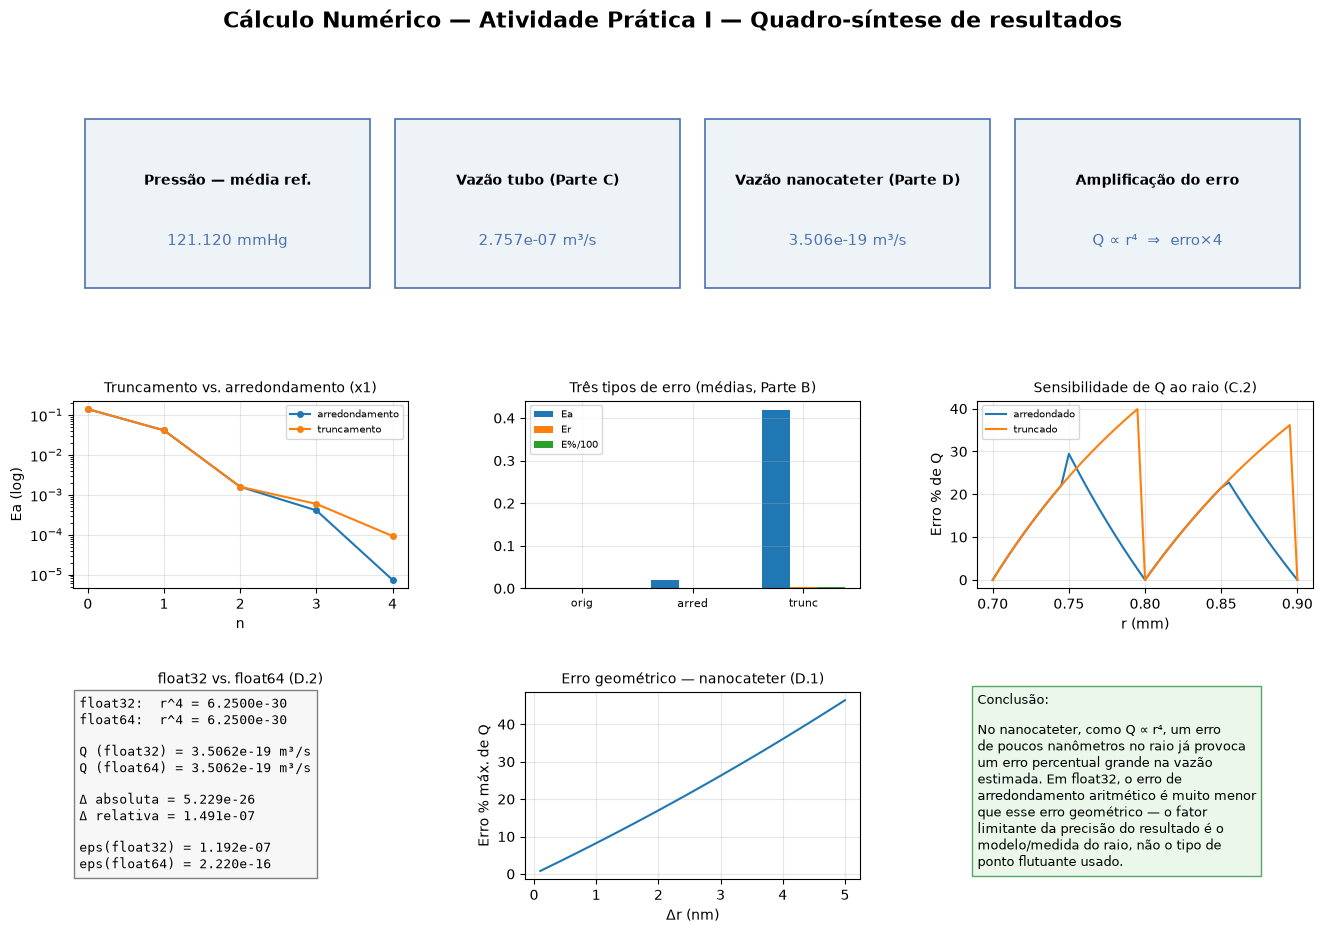

Tamanho do PNG gerado (px): (1600, 1000)


In [40]:
fig = plt.figure(figsize=(16, 10), dpi=100)  # 1600 x 1000 px em dpi=100
gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.35)
fig.suptitle(
    "Cálculo Numérico — Atividade Prática I — Quadro-síntese de resultados",
    fontsize=16,
    fontweight="bold",
)

# --- cartões com os principais valores de pressão e vazão ---
ax_cards = fig.add_subplot(gs[0, :])
ax_cards.axis("off")
cartoes = [
    ("Pressão — média ref.", f"{media_ref:.3f} mmHg"),
    ("Vazão tubo (Parte C)", f"{Q_ref_C:.3e} m³/s"),
    ("Vazão nanocateter (Parte D)", f"{Q_ref_D:.3e} m³/s"),
    ("Amplificação do erro", "Q ∝ r⁴  ⇒  erro×4"),
]
n_cartoes = len(cartoes)
for i, (titulo, valor) in enumerate(cartoes):
    x0 = i / n_cartoes
    rect = plt.Rectangle(
        (x0 + 0.01, 0.05),
        1 / n_cartoes - 0.02,
        0.9,
        transform=ax_cards.transAxes,
        facecolor="#EEF3F8",
        edgecolor="#4C72B0",
        linewidth=1.2,
    )
    ax_cards.add_patch(rect)
    ax_cards.text(
        x0 + 1 / (2 * n_cartoes),
        0.62,
        titulo,
        transform=ax_cards.transAxes,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
    )
    ax_cards.text(
        x0 + 1 / (2 * n_cartoes),
        0.30,
        valor,
        transform=ax_cards.transAxes,
        ha="center",
        va="center",
        fontsize=11,
        color="#4C72B0",
    )

# --- comparação truncamento x arredondamento (Parte A, x1) ---
ax1 = fig.add_subplot(gs[1, 0])
sub = df_A[df_A["variavel"].str.startswith("x1")]
for metodo, grupo in sub.groupby("metodo"):
    grupo = grupo.sort_values("n")
    ax1.plot(grupo["n"], grupo["Ea"].replace(0, 1e-18), "-o", label=metodo, ms=4)
ax1.set_yscale("log")
ax1.set_xlabel("n")
ax1.set_ylabel("Ea (log)")
ax1.set_title("Truncamento vs. arredondamento (x1)", fontsize=10)
ax1.legend(fontsize=7)

# --- os três tipos de erro (Parte B, medias) ---
ax2 = fig.add_subplot(gs[1, 1])
largura = 0.25
idx = np.arange(len(df_B))
ax2.bar(idx - largura, df_B["Ea"], width=largura, label="Ea")
ax2.bar(idx, df_B["Er"], width=largura, label="Er")
ax2.bar(idx + largura, df_B["E%"] / 100, width=largura, label="E%/100")
ax2.set_xticks(idx)
ax2.set_xticklabels(["orig", "arred", "trunc"], fontsize=8)
ax2.set_title("Três tipos de erro (médias, Parte B)", fontsize=10)
ax2.legend(fontsize=7)

# --- sensibilidade de Q ao raio (Parte C.2) ---
ax3 = fig.add_subplot(gs[1, 2])
ax3.plot(r_mm_grid, erro_percentual(Q_ref_grid, Q_arred_grid), label="arredondado")
ax3.plot(r_mm_grid, erro_percentual(Q_ref_grid, Q_trunc_grid), label="truncado")
ax3.set_xlabel("r (mm)")
ax3.set_ylabel("Erro % de Q")
ax3.set_title("Sensibilidade de Q ao raio (C.2)", fontsize=10)
ax3.legend(fontsize=7)

# --- comparação float32 x float64 ---
ax4 = fig.add_subplot(gs[2, 0])
ax4.axis("off")
texto_precisao = (
    f"float32:  r^4 = {r4_32:.4e}\n"
    f"float64:  r^4 = {r4_64:.4e}\n\n"
    f"Q (float32) = {Q32:.4e} m³/s\n"
    f"Q (float64) = {Q64:.4e} m³/s\n\n"
    f"Δ absoluta = {diff_abs:.3e}\n"
    f"Δ relativa = {diff_rel:.3e}\n\n"
    f"eps(float32) = {np.finfo(np.float32).eps:.3e}\n"
    f"eps(float64) = {np.finfo(np.float64).eps:.3e}"
)
ax4.text(
    0.02,
    0.98,
    texto_precisao,
    transform=ax4.transAxes,
    va="top",
    fontsize=9,
    family="monospace",
    bbox={"facecolor": "#F7F7F7", "edgecolor": "gray"},
)
ax4.set_title("float32 vs. float64 (D.2)", fontsize=10)

# --- erro geométrico do nanocateter (Parte D.1) ---
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(dr_nm, Ep_max)
ax5.set_xlabel("Δr (nm)")
ax5.set_ylabel("Erro % máx. de Q")
ax5.set_title("Erro geométrico — nanocateter (D.1)", fontsize=10)

# --- conclusão curta sobre o nanocateter ---
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis("off")
conclusao_curta = (
    "Conclusão:\n\n"
    "No nanocateter, como Q ∝ r⁴, um erro\n"
    "de poucos nanômetros no raio já provoca\n"
    "um erro percentual grande na vazão\n"
    "estimada. Em float32, o erro de\n"
    "arredondamento aritmético é muito menor\n"
    "que esse erro geométrico — o fator\n"
    "limitante da precisão do resultado é o\n"
    "modelo/medida do raio, não o tipo de\n"
    "ponto flutuante usado."
)
ax6.text(
    0.0,
    1.0,
    conclusao_curta,
    transform=ax6.transAxes,
    va="top",
    fontsize=9,
    bbox={"facecolor": "#EAF7EA", "edgecolor": "#55A868"},
)

fig.savefig("quadro_resultados.png", dpi=100)  # 16*100 x 10*100 = 1600 x 1000 px
plt.show()

img_check = Image.open("quadro_resultados.png")
print("Tamanho do PNG gerado (px):", img_check.size)


## GIF demonstrativo

40 quadros, raio do nanocateter variando de 45 a 55 nm. Cada quadro mostra a seção
transversal do canal, o raio e a vazão atuais, o erro percentual em relação a $r=50$ nm, e a
curva $Q\times r$ sendo construída progressivamente.

In [41]:
n_frames = 40
r_gif_nm = np.linspace(45, 55, n_frames)
r_gif_m = r_gif_nm * 1e-9
Q_gif = vazao_hagen_poiseuille(r_gif_m, dp_D, mu_D, L_D)
r0_nm = 50.0
Q0 = vazao_hagen_poiseuille(r0_nm * 1e-9, dp_D, mu_D, L_D)
erro_pct_gif = erro_percentual(Q0, Q_gif)

fig, (ax_sec, ax_curva) = plt.subplots(1, 2, figsize=(9, 4.2))


def desenhar_quadro(i):
    ax_sec.clear()
    ax_curva.clear()

    # --- seção transversal do canal ---
    r_atual = r_gif_nm[i]
    circ = Circle(
        (0, 0), r_atual, facecolor="#A9CCE3", edgecolor="#2E5A87", linewidth=1.5
    )
    ax_sec.add_patch(circ)
    ax_sec.set_xlim(-30, 30)
    ax_sec.set_ylim(-30, 30)
    ax_sec.set_aspect("equal")
    ax_sec.set_title("Seção transversal do nanocateter")
    ax_sec.set_xlabel("nm")
    ax_sec.set_ylabel("nm")
    texto = (
        f"r = {r_atual:.2f} nm\n"
        f"Q = {Q_gif[i]:.3e} m³/s\n"
        f"Erro % vs r=50nm: {erro_pct_gif[i]:.2f}%"
    )
    ax_sec.text(
        0.03,
        0.97,
        texto,
        transform=ax_sec.transAxes,
        va="top",
        fontsize=8,
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "gray"},
    )

    # --- curva Q x r sendo construida progressivamente ---
    ax_curva.plot(r_gif_nm[: i + 1], Q_gif[: i + 1] * 1e21, "-o", ms=3, color="#DD8452")
    ax_curva.set_xlim(r_gif_nm.min(), r_gif_nm.max())
    ax_curva.set_ylim(Q_gif.min() * 1e21 * 0.95, Q_gif.max() * 1e21 * 1.05)
    ax_curva.axvline(50, color="gray", ls=":", lw=1)
    ax_curva.set_xlabel("r (nm)")
    ax_curva.set_ylabel("Q (×10⁻²¹ m³/s)")
    ax_curva.set_title("Curva Q × r (construção progressiva)")

    fig.tight_layout()
    return []


anim = FuncAnimation(fig, desenhar_quadro, frames=n_frames, blit=False)
anim.save("nanocateter.gif", writer=PillowWriter(fps=8))
plt.close(fig)
print("GIF salvo: nanocateter.gif")


GIF salvo: nanocateter.gif


## Conclusão

Este trabalho evidenciou, de forma progressiva, como pequenas escolhas de representação
numérica (truncar vs. arredondar, `float32` vs. `float64`) e pequenas incertezas de medição
se propagam de maneiras muito diferentes dependendo da estrutura matemática do problema: erros
de arredondamento tendem a ser pequenos e a se cancelar em médias, mas quando uma grandeza
física depende de uma potência alta de outra — como a vazão de Hagen–Poiseuille, proporcional
a $r^4$ — mesmo incertezas milimétricas (Parte C) ou nanométricas (Parte D) no raio são
amplificadas em fator 4 na vazão resultante. Em escalas muito pequenas, além disso, a precisão
puramente aritmética (mais casas decimais, `float64` em vez de `float32`) deixa de ser o
fator limitante: o próprio modelo contínuo de Hagen–Poiseuille passa a ser fisicamente menos
adequado à medida que a razão superfície/volume cresce e efeitos de parede dominam o
escoamento em um nanocateter. Em suma, precisão numérica e validade física são dimensões
independentes do problema, e ambas precisam ser consideradas ao interpretar um resultado de
engenharia em micro/nanoescala.